### Pre-process step 2
- Performs wavelength calibration to camera pixels.
- Needs:
    - CalibrationImage.tiff from pre-process set 1
- Uses the prism Sellmeier equation for the material N-SF11 to fit wavelength to pixels.
- Saves:
    - A a 300x2 matrix in .hdf5 format with pixels as one column and wavelength that corresponds to that pixel as a second column. 

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from PIL import Image
from scipy.signal import find_peaks
import pandas as pd
from pathlib import Path
import h5py

%matplotlib inline

In [2]:
# VARIABLES THAT CAN BE MODIFIED IN THE SCRIPT:
# session_id (identifies the session being analyzed)
# theta_I (angle of incidience, specific to the optical alignment of the rig. Should be a fixed value)
    # NOTE: theta_I and alpha are currently defined in multiple cells! Would need to edit all if changing these values

# Note 10/21/25: need to finalize path to calibration files, these should be fixed and not modifiable run to run
# Note 11/3/25: fix overwriting of 'n' in multiple cells (refractive index as a function of wavelength)

In [3]:
# Enter the session id
session_id = 'HSFP_775510_2025-02-20_11-08-27'

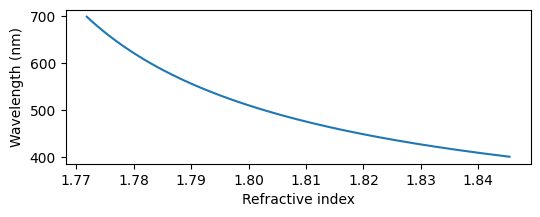

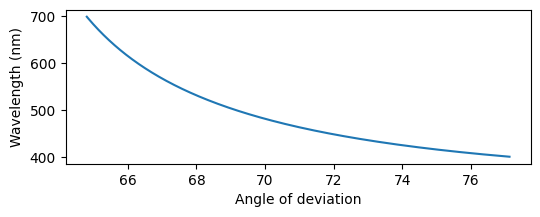

In [4]:
# Calculate and plot the refractive index of SCOTT optical glass N-SF11
# Create an array of wavelengths in the visible spectrum 
wavelength = np.arange(0.4,0.7,0.001) # array goes from 400nm to 700nm with a step size of 1nm


# Compute the refractive index as a function of wavelength using the Sellmeier dispersion formula for N-SF11
n = np.sqrt(1 + ((1.73759695*wavelength**2)/((wavelength**2)-0.013188707)) + ((0.313747356*wavelength**2)/((wavelength**2)-0.0623068142)) + ((1.89878101*wavelength**2)/((wavelength**2)-155.23629)))

# Plot the refractive index vs wavelength
f, ax = plt.subplots(figsize=(6,2))
ax.plot(n, 1000*wavelength) # convert the wavelength from um to nm for better readability
ax.set(ylabel='Wavelength (nm)', xlabel='Refractive index')
plt.show()

# Define prism geometry needed to compute the angle of deviation
theta_I = 60.8 # theta_I = angle of incidence of the incoming light on the first face (specific to the HSFP system's optical alignment)
alpha = 60 # alpha = prism apex angle (physical constant for the prism itself from manufacturer data sheet; the angle between the two refracting faces of the prism)

# Calculate the deviation angle for each wavelength (based on Snell's Law, computes how much the light beam is deflected
# after passing through the prism for each wavlength)
theta_D = theta_I - alpha + np.rad2deg(np.arcsin((np.sin(np.deg2rad(alpha))*np.sqrt(n**2 - np.sin(np.deg2rad(theta_I))**2)) - (np.sin(np.deg2rad(theta_I))*np.cos(np.deg2rad(alpha)))))

# Plot the angle of deviation vs wavelength
f, ax = plt.subplots(figsize=(6,2))
ax.plot(theta_D, 1000*wavelength) # convert the wavelength from um to nm for better readability
ax.set(ylabel='Wavelength (nm)', xlabel='Angle of deviation')
plt.show()

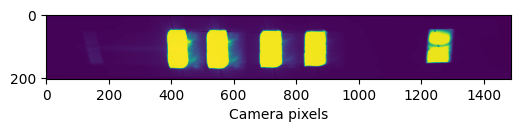

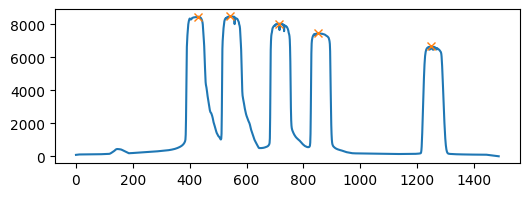

X-coordinates of each laser's center: 


array([ 430,  543,  715,  853, 1250])

In [5]:
# Plot the calibration image with all 5 lasers turned on (generated in preprocess step 1)

# Load calibration sequence image
# point to the results directory
results_dir = Path('/results/')

# Open the calibration image generated in preprocess step 1 (located in results folder)
I = Image.open(results_dir / 'CalibrationImage.tiff')

# convert the image into a 3D numpy array (num_frames, height, width)
im = np.array(I) 

# Display the calibration image
f,ax = plt.subplots(figsize=(6,6))
ax.imshow(im)
ax.set(xlabel='Camera pixels')
ax.grid(False)

# Extract center position of each laser from image
im_line = np.mean(im,axis=0) # take the mean intensity across rows, creating a 1D intensity profile along the horizontal direction
laser_pix, _ = find_peaks(im_line, height=4000, distance=100) #find peaks brighter than 4000 and at least 100 pixels apart

# Plot the intensity profile with detected peaks
f, ax = plt.subplots(figsize=(6,2))
ax.plot(im_line)
ax.plot(laser_pix, im_line[laser_pix], 'x')
plt.show()

# Print the x-coordinates of the peaks where each laser is located
print('X-coordinates of each laser\'s center: ')
laser_pix

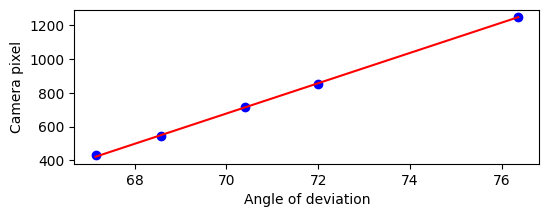

Calibration parameters [slope, intercept] of the optimization curve: 


array([   89.66242989, -5598.70585922])

In [6]:
# Fit a relationship between each wavelength and its pixel position on the camera sensor

# Optimization function to return pixel value given angle of deviation as input
# f_lambda_r: pixel position of a reference wavelength that makes a right angle with the camera sensor
# r: distance from convergence point (prism) to camera sensor
# theta_D_r: angle of deviation of the right angled reference wavelength

# Original fit (nonlinear gemoetric optics model:)
# def wave(xdata, f_lambda_r, r, theta_D_r): 
    #return np.tan(np.deg2rad(theta_D_r - xdata))*r + f_lambda_r

# Changed fit to a linear fit
def wave(xdata, a, b): 
    return a*xdata + b

lasers = np.array([0.561, 0.514, 0.473, 0.448, 0.405]) # Lasers used for calibration, in um
theta_I = 60.8 # Angle of incidence on the prism
alpha = 60 # Apex angle of prism

# Compute the refractive index for each laser using the Sellmeier equation for N-SF11 glass; returns refractive index 'n' as a function of wavelength
n = np.sqrt(1 + ((1.73759695*lasers**2)/((lasers**2)-0.013188707)) + ((0.313747356*lasers**2)/((lasers**2)-0.0623068142)) + ((1.89878101*lasers**2)/((lasers**2)-155.23629)))

# Compute angle of deviation for each wavelength (based on Snell's law)
xdata = theta_I - alpha + np.rad2deg(np.arcsin((np.sin(np.deg2rad(alpha))*np.sqrt(n**2 - np.sin(np.deg2rad(theta_I))**2)) - (np.sin(np.deg2rad(theta_I))*np.cos(np.deg2rad(alpha)))))

# Save the pixel positions where the lasers ended up on the camera as 'ydata'
ydata = laser_pix

# Fit the calibration curve
# popt, pcov = curve_fit(wave, xdata, ydata, bounds=([1, -np.inf, 60],[2048, np.inf, 80]))
popt, pcov = curve_fit(wave, xdata, ydata) # finds the best parameters a and b in the linear equation defined by wave

# Visualize the linear fit along with the observed data to confirm calibratoin worked correctly
f, ax = plt.subplots(figsize=(6,2))
ax.plot(xdata, ydata, 'bo')
ax.plot(xdata, wave(xdata, *popt), 'r-')
ax.set(ylabel='Camera pixel', xlabel='Angle of deviation')
plt.show()

# Print the calibration parameters
print('Calibration parameters [slope, intercept] of the optimization curve: ')
popt

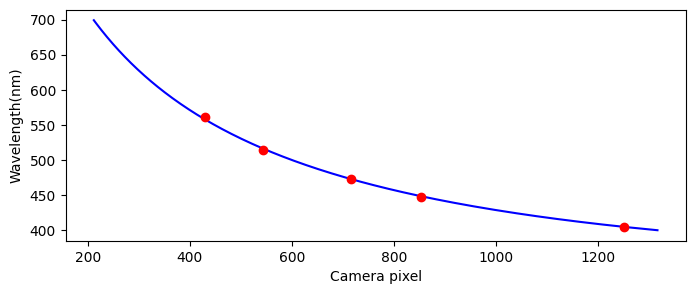

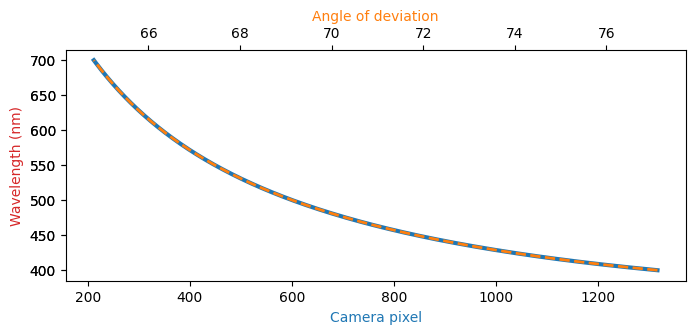

     Camera_pixel  Wavelength_nm
0            1664            400
1            1650            401
2            1636            402
3            1622            403
4            1609            404
..            ...            ...
295           564            695
296           563            696
297           562            697
298           561            698
299           560            699

[300 rows x 2 columns]
892
516


In [7]:
# From the optimization curve, extract pixel position for all wavelengths

# Create an array of wavelengths in the visible spectrum
wavelength = np.arange(0.4,0.7,0.001) # array goes from 400nm to 700nm with a step size of 1nm

# Compute the refractive index as a function of wavelength
n = np.sqrt(1 + ((1.73759695*wavelength**2)/((wavelength**2)-0.013188707)) + ((0.313747356*wavelength**2)/((wavelength**2)-0.0623068142)) + ((1.89878101*wavelength**2)/((wavelength**2)-155.23629)))

# Compute the angle of deviation for each wavelength
theta_I = 60.8
alpha = 60
theta_D = theta_I - alpha + np.rad2deg(np.arcsin((np.sin(np.deg2rad(alpha))*np.sqrt(n**2 - np.sin(np.deg2rad(theta_I))**2)) - (np.sin(np.deg2rad(theta_I))*np.cos(np.deg2rad(alpha)))))

# Convert the deviation angle to the camera pixel position by applying the fitted calibratoin curve
#pixel_value = wave(theta_D, popt[0],popt[1],popt[2])
pixel_value = wave(theta_D, popt[0],popt[1])

# Plot wavelength vs camera pixel
f, ax = plt.subplots(figsize=(8,3))
ax.plot(pixel_value, 1000*wavelength, 'b-') # model-predicted relationship (pixel --> wavelength)
ax.plot(laser_pix, 1000*lasers, 'ro') # measured calibration lasers
ax.set(xlabel='Camera pixel', ylabel='Wavelength(nm)')
plt.show()

# Overlay two x-axes (pixel vs deviation angle)
fig = plt.figure(figsize=(8,3))
ax1 = fig.add_subplot(111, label='1')
ax1.plot(pixel_value, 1000*wavelength, color='C0', linewidth=3)
ax1.set_xlabel('Camera pixel', color='C0')
ax1.set_ylabel('Wavelength (nm)', color='C3')
ax2 = fig.add_subplot(111, label='2', frame_on=False)
ax2.plot(theta_D, 1000*wavelength, '--', color='C1', linewidth=2)
ax2.xaxis.tick_top()
ax2.set_xlabel('Angle of deviation', color='C1')
ax2.xaxis.set_label_position('top') 
plt.show()

# Read from calibration.txt
with open(os.path.join(results_dir, 'calibration.txt'),'r') as f:
    for line in f:
        name, value = line.strip().split(' = ') # read parameters stored in the calibration.txt file
        exec(f'{name} = {value}')

# Apply the x-offset and round pixel positions to integers
pixel_value_new = calib_Xoffset + np.round(pixel_value).astype(int)

# Build the Lookup Table as a DataFrame that maps each camera pixel to its corresponding wavelength
LUT = {'Camera_pixel':pixel_value_new, 'Wavelength_nm': (1000*wavelength).astype(int)}
lut = pd.DataFrame(data=LUT)
print(lut)
idx = 116
print(lut.Camera_pixel[idx])
print(lut.Wavelength_nm[idx])

In [10]:
# write h5 file with pandas dataframe
store = pd.HDFStore(results_dir / 'pixel_to_nm.hdf5')
for key in lut.keys():
    lut[key].to_hdf(store, key=key, mode='a')
store.close()

with h5py.File(results_dir /'pixel_to_nm.hdf5', 'r') as f:
    print(f.keys())
    

<KeysViewHDF5 ['Camera_pixel', 'Wavelength_nm']>


In [1]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit
# from PIL import Image
# from scipy.signal import find_peaks
# import pandas as pd
# import h5py

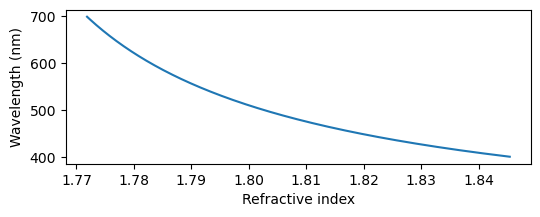

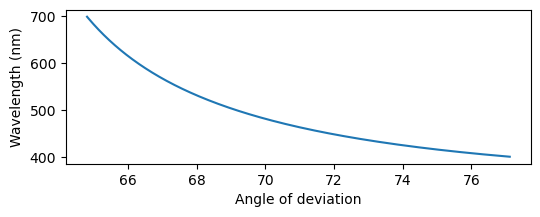

In [2]:
# # Refractive index of N-SF11
# wavelength = np.arange(0.4,0.7,0.001)

# # Sellmeier equation for N-SF11
# n = np.sqrt(1 + ((1.73759695*wavelength**2)/((wavelength**2)-0.013188707)) + ((0.313747356*wavelength**2)/((wavelength**2)-0.0623068142)) + ((1.89878101*wavelength**2)/((wavelength**2)-155.23629)))
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(n, 1000*wavelength)
# ax.set(ylabel='Wavelength (nm)', xlabel='Refractive index')
# plt.show()

# # Angle of deviation
# theta_I = 60.8
# alpha = 60
# theta_D = theta_I - alpha + np.rad2deg(np.arcsin((np.sin(np.deg2rad(alpha))*np.sqrt(n**2 - np.sin(np.deg2rad(theta_I))**2)) - (np.sin(np.deg2rad(theta_I))*np.cos(np.deg2rad(alpha)))))
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(theta_D, 1000*wavelength)
# ax.set(ylabel='Wavelength (nm)', xlabel='Angle of deviation')
# plt.show()

Paths are for dataset tagged: all


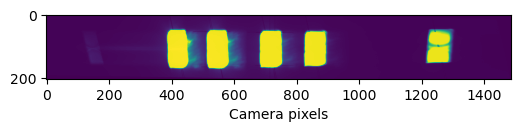

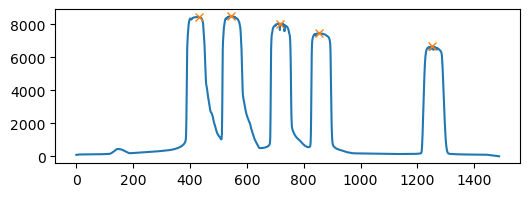

array([ 430,  543,  715,  853, 1250], dtype=int64)

In [3]:
# # Calibration image with 5 lasers turned on
# from config import load_config
# paths = load_config(dataset_key='all')
# I = Image.open(paths['raw_data'] / 'CalibrationImage.tiff')

# im = np.array(I)
# f,ax = plt.subplots(figsize=(6,6))
# ax.imshow(im)
# ax.set(xlabel='Camera pixels')
# ax.grid(False)

# # Extract center position of laser from image
# im_line = np.mean(im,axis=0)
# laser_pix, _ = find_peaks(im_line, height=4000, distance=100)
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(im_line)
# ax.plot(laser_pix, im_line[laser_pix], 'x')
# plt.show()
# laser_pix

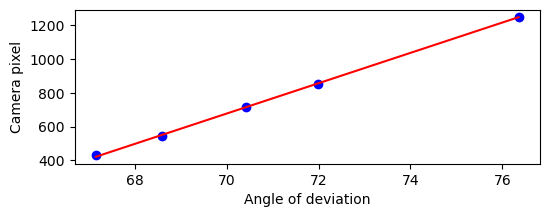

array([   89.66242989, -5598.70585922])

In [4]:
# # Optimization function to return pixel value given angle of deviation as input
# # f_lambda_r: pixel position of wavelength that makes a right angle with the camera sensor
# # r: distance from convergence point to camera sensor
# # theta_D_r: angle of deviation of the right angled wavelength
# # def wave(xdata, f_lambda_r, r, theta_D_r): 
#     #return np.tan(np.deg2rad(theta_D_r - xdata))*r + f_lambda_r

# # Changed fit to a linear fit
# def wave(xdata, a, b): 
#     return a*xdata + b

# lasers = np.array([0.561, 0.514, 0.473, 0.448, 0.405]) # Lasers use for calibration
# theta_I = 60.8 # Angle of incidence
# alpha = 60 # Apex angle of prism
# n = np.sqrt(1 + ((1.73759695*lasers**2)/((lasers**2)-0.013188707)) + ((0.313747356*lasers**2)/((lasers**2)-0.0623068142)) + ((1.89878101*lasers**2)/((lasers**2)-155.23629)))
# xdata = theta_I - alpha + np.rad2deg(np.arcsin((np.sin(np.deg2rad(alpha))*np.sqrt(n**2 - np.sin(np.deg2rad(theta_I))**2)) - (np.sin(np.deg2rad(theta_I))*np.cos(np.deg2rad(alpha)))))
# ydata = laser_pix
# # popt, pcov = curve_fit(wave, xdata, ydata, bounds=([1, -np.inf, 60],[2048, np.inf, 80]))
# popt, pcov = curve_fit(wave, xdata, ydata)

# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(xdata, ydata, 'bo')
# ax.plot(xdata, wave(xdata, *popt), 'r-')
# ax.set(ylabel='Camera pixel', xlabel='Angle of deviation')
# plt.show()
# popt

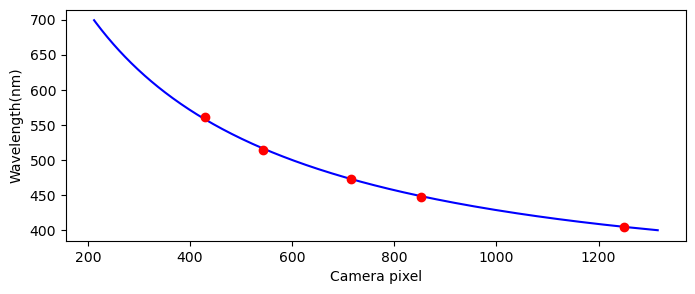

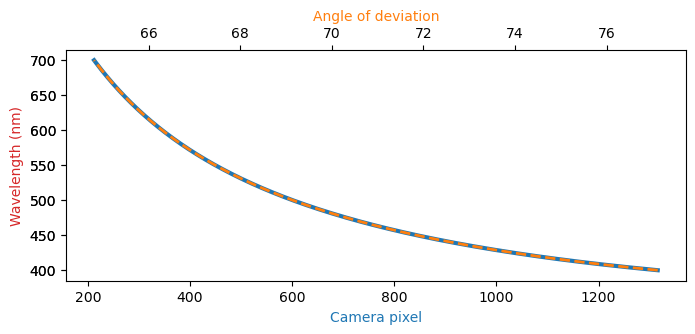

     Camera_pixel  Wavelength_nm
0            1664            400
1            1650            401
2            1636            402
3            1622            403
4            1609            404
..            ...            ...
295           564            695
296           563            696
297           562            697
298           561            698
299           560            699

[300 rows x 2 columns]
892
516


In [5]:
# # From optimization curve, extract pixel position for all wavelengths
# wavelength = np.arange(0.4,0.7,0.001)
# n = np.sqrt(1 + ((1.73759695*wavelength**2)/((wavelength**2)-0.013188707)) + ((0.313747356*wavelength**2)/((wavelength**2)-0.0623068142)) + ((1.89878101*wavelength**2)/((wavelength**2)-155.23629)))
# theta_I = 60.8
# alpha = 60
# theta_D = theta_I - alpha + np.rad2deg(np.arcsin((np.sin(np.deg2rad(alpha))*np.sqrt(n**2 - np.sin(np.deg2rad(theta_I))**2)) - (np.sin(np.deg2rad(theta_I))*np.cos(np.deg2rad(alpha)))))
# #pixel_value = wave(theta_D, popt[0],popt[1],popt[2])
# pixel_value = wave(theta_D, popt[0],popt[1])

# f, ax = plt.subplots(figsize=(8,3))
# ax.plot(pixel_value, 1000*wavelength, 'b-')
# ax.plot(laser_pix, 1000*lasers, 'ro')
# ax.set(xlabel='Camera pixel', ylabel='Wavelength(nm)')
# plt.show()

# fig = plt.figure(figsize=(8,3))
# ax1 = fig.add_subplot(111, label='1')
# ax1.plot(pixel_value, 1000*wavelength, color='C0', linewidth=3)
# ax1.set_xlabel('Camera pixel', color='C0')
# ax1.set_ylabel('Wavelength (nm)', color='C3')
# ax2 = fig.add_subplot(111, label='2', frame_on=False)
# ax2.plot(theta_D, 1000*wavelength, '--', color='C1', linewidth=2)
# ax2.xaxis.tick_top()
# ax2.set_xlabel('Angle of deviation', color='C1')
# ax2.xaxis.set_label_position('top') 
# plt.show()

# # Read from calibration.txt
# with open(paths['raw_data'] / 'calibration.txt', 'r') as f:
#     for line in f:
#         name, value = line.strip().split(' = ')
#         exec(f'{name} = {value}')

# pixel_value_new = calib_Xoffset + np.round(pixel_value).astype(int)
# LUT = {'Camera_pixel':pixel_value_new, 'Wavelength_nm': (1000*wavelength).astype(int)}
# lut = pd.DataFrame(data=LUT)
# print(lut)
# idx = 116
# print(lut.Camera_pixel[idx])
# print(lut.Wavelength_nm[idx])

In [6]:
# # write h5 file with pandas dataframe
# import tables as tb
# store = pd.HDFStore(paths['raw_data']/'pixel_to_nm.hdf5')
# for key in lut.keys():
#     lut[key].to_hdf(store, key=key, mode='a')
# store.close()

# with h5py.File(paths['raw_data']/'pixel_to_nm.hdf5', 'r') as f:
#     print(f.keys())
    

<KeysViewHDF5 ['Camera_pixel', 'Wavelength_nm']>
